In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar datos
data = pd.read_csv("ENB2012_data.csv")


El conjunto de datos fue creado por Angeliki Xifara (angxifara '@' gmail.com, Ingeniera Civil/Estructural) y fue procesado por Athanasios Tsanas (tsanasthanasis '@' gmail.com, Centro de Oxford para Matemáticas Industriales y Aplicadas, Universidad de Oxford, Reino Unido).

Información del Conjunto de Datos:

Realizamos un análisis energético utilizando 12 formas de edificios diferentes simuladas en Ecotect. Los edificios difieren en cuanto al área de acristalamiento, la distribución del área de acristalamiento y la orientación, entre otros parámetros. Simulamos varias configuraciones como funciones de las características mencionadas anteriormente para obtener 768 formas de edificios. El conjunto de datos comprende 768 muestras y 8 características, con el objetivo de predecir dos respuestas de valores reales. También se puede utilizar como un problema de clasificación multi-clase si la respuesta se redondea al entero más cercano.

Información de los Atributos:

El conjunto de datos contiene ocho atributos (o características, denotadas por X1...X8) y dos respuestas (o resultados, denotadas por y1 y y2). El objetivo es utilizar las ocho características para predecir cada una de las dos respuestas.

Específicamente:
X1 Compacidad Relativa
X2 Área de Superficie
X3 Área de Pared
X4 Área de Techo
X5 Altura Total
X6 Orientación
X7 Área de Acristalamiento
X8 Distribución del Área de Acristalamiento
y1 Carga de Calefacción
y2 Carga de Refrigeración

In [12]:
data.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')

In [13]:

# Dividir datos en características (X) y objetivos (y)
X = data.drop(columns=['Y1', 'Y2'])
y_heating = data['Y1']
y_cooling = data['Y2']

# Dividir datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train_heating, y_test_heating, y_train_cooling, y_test_cooling = train_test_split(X, y_heating, y_cooling, test_size=0.2, random_state=42)


In [14]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

# Construir modelo de red neuronal para la carga de calefacción
model_heating = Sequential()
model_heating.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model_heating.add(Dense(32, activation='relu'))
model_heating.add(Dense(1))

# Compilar modelo
model_heating.compile(loss='mean_squared_error', optimizer=Adam(lr=0.001))

# Entrenar modelo
model_heating.fit(X_train, y_train_heating, epochs=50, batch_size=32, validation_split=0.2)


Epoch 1/50


h:\Anaconda\envs\IA\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


16/16 [==============================] - 0s 11ms/step - loss: 311.7090 - val_loss: 118.2643
Epoch 2/50
16/16 [==============================] - 0s 4ms/step - loss: 63.7909 - val_loss: 46.9961
Epoch 3/50
16/16 [==============================] - 0s 4ms/step - loss: 43.0393 - val_loss: 36.0963
Epoch 4/50
16/16 [==============================] - 0s 5ms/step - loss: 38.4738 - val_loss: 33.8632
Epoch 5/50
16/16 [==============================] - 0s 5ms/step - loss: 35.9955 - val_loss: 34.4859
Epoch 6/50
16/16 [==============================] - 0s 4ms/step - loss: 35.8564 - val_loss: 37.1538
Epoch 7/50
16/16 [==============================] - 0s 4ms/step - loss: 34.9763 - val_loss: 36.3340
Epoch 8/50
16/16 [==============================] - 0s 5ms/step - loss: 34.2976 - val_loss: 36.6707
Epoch 9/50
16/16 [==============================] - 0s 4ms/step - loss: 35.8797 - val_loss: 32.2636
Epoch 10/50
16/16 [==============================] - 0s 4ms/step - loss: 34.3459 - val_loss: 30.5824
Epoch 1

5/5 [==============================] - 0s 2ms/step - loss: 15.9667
Loss (Heating Load): 15.966724395751953
5/5 [==============================] - 0s 1ms/step


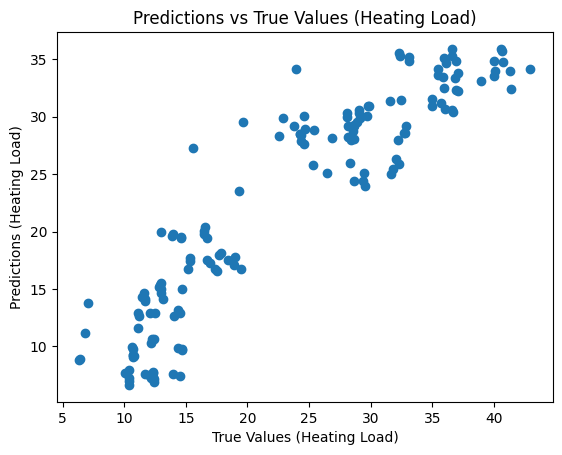

In [15]:
import matplotlib.pyplot as plt

# Evaluar modelo de carga de calefacción en conjunto de prueba
loss_heating = model_heating.evaluate(X_test, y_test_heating)
print("Loss (Heating Load):", loss_heating)

# Predicciones de carga de calefacción en conjunto de prueba
predictions_heating = model_heating.predict(X_test)

# Visualizar predicciones vs valores reales de carga de calefacción
plt.scatter(y_test_heating, predictions_heating)
plt.xlabel('True Values (Heating Load)')
plt.ylabel('Predictions (Heating Load)')
plt.title('Predictions vs True Values (Heating Load)')
plt.show()


In [16]:
# Construir modelo de red neuronal para la carga de calefacción
model_cooling = Sequential()
model_cooling.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model_cooling.add(Dense(32, activation='relu'))
model_cooling.add(Dense(1))

# Compilar modelo
model_cooling.compile(loss='mean_squared_error', optimizer=Adam(lr=0.001))

# Entrenar modelo
model_cooling.fit(X_train, y_train_cooling, epochs=50, batch_size=32, validation_split=0.2)


Epoch 1/50


h:\Anaconda\envs\IA\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


16/16 [==============================] - 0s 11ms/step - loss: 205.4428 - val_loss: 116.8313
Epoch 2/50
16/16 [==============================] - 0s 4ms/step - loss: 87.3116 - val_loss: 56.0410
Epoch 3/50
16/16 [==============================] - 0s 5ms/step - loss: 49.5451 - val_loss: 37.2145
Epoch 4/50
16/16 [==============================] - 0s 4ms/step - loss: 43.4840 - val_loss: 33.8635
Epoch 5/50
16/16 [==============================] - 0s 4ms/step - loss: 47.6560 - val_loss: 31.4307
Epoch 6/50
16/16 [==============================] - 0s 4ms/step - loss: 35.1854 - val_loss: 30.4273
Epoch 7/50
16/16 [==============================] - 0s 5ms/step - loss: 33.0423 - val_loss: 30.3535
Epoch 8/50
16/16 [==============================] - 0s 4ms/step - loss: 35.9966 - val_loss: 38.6108
Epoch 9/50
16/16 [==============================] - 0s 5ms/step - loss: 33.8013 - val_loss: 28.2237
Epoch 10/50
16/16 [==============================] - 0s 4ms/step - loss: 30.5962 - val_loss: 41.1614
Epoch 1

5/5 [==============================] - 0s 0s/step - loss: 16.0669
Loss (Cooling Load): 16.066890716552734
5/5 [==============================] - 0s 0s/step


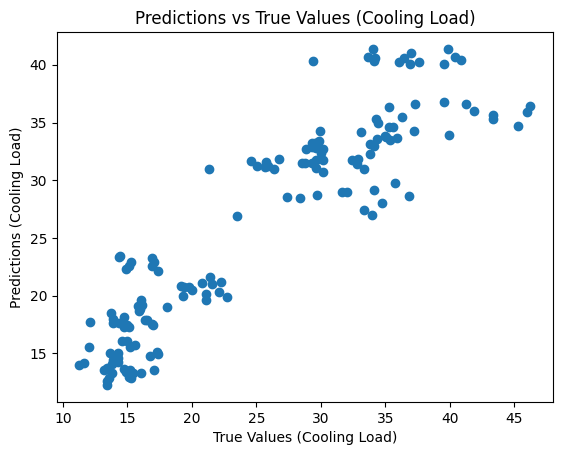

In [17]:
# Evaluar modelo de carga de refrigeración en conjunto de prueba
loss_cooling = model_cooling.evaluate(X_test, y_test_cooling)
print("Loss (Cooling Load):", loss_cooling)

# Predicciones de carga de refrigeración en conjunto de prueba
predictions_cooling = model_cooling.predict(X_test)

# Visualizar predicciones vs valores reales de carga de refrigeración
plt.scatter(y_test_cooling, predictions_cooling)
plt.xlabel('True Values (Cooling Load)')
plt.ylabel('Predictions (Cooling Load)')
plt.title('Predictions vs True Values (Cooling Load)')
plt.show()